# 1D Signal Decomposition

This notebook walks through `TopNMF` on 1-D time-series, contrasting two
topological priors:

- **Part A** -- Periodic vs non-periodic separation (Vietoris-Rips persistence via time-delay embedding)
- **Part B** -- Unimodal basis (1-D cubical persistence)


## Setup

In [1]:
import os
from pathlib import Path

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.signal as sp_signal
import scipy.datasets as sp_datasets
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import NMF
from typing import Optional, Tuple

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    weighted_total_squared_persistence_loss,
    compute_periodicity_score,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

np.random.seed(42)

_cwd = os.path.abspath("")
_NOTEBOOK_DIR = _cwd if os.path.basename(_cwd) == "notebook" \
    else os.path.join(_cwd, "notebook")
DATA_DIR = os.path.join(_NOTEBOOK_DIR, "data")
OUTPUT_DIR = os.path.join(_NOTEBOOK_DIR, "output")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


def download_cached(url: str, filename: str) -> str:
    """Download *url* to ``DATA_DIR/filename`` (skip if already present)."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {url}\n  -> {path}")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as r, open(path, "wb") as f:
            f.write(r.read())
    return path


# ---------- evaluation helpers -----------------------------------------------

def _row_normalize(M: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.where(norms > 0, norms, 1.0)


def atom_recovery_score(V_est: np.ndarray, atoms_true: np.ndarray) -> float:
    """Mean cosine similarity between estimated and true atoms under optimal assignment."""
    A = _row_normalize(V_est)
    B = _row_normalize(atoms_true)
    cost = -A @ B.T
    row, col = linear_sum_assignment(cost)
    return float(-cost[row, col].mean())


def count_modes(v: np.ndarray, threshold: float = 0.10, prominence: float = 0.05) -> int:
    """Count peaks via ``scipy.signal.find_peaks`` with a relative prominence
    cut-off. Unimodal -> 1.

    A plain "v[i] is greater than its neighbours" test counts every wiggle on a
    plateau, even when the wiggles are sub-noise. We require the peak to rise
    above ``threshold * max(v)`` *and* have prominence at least
    ``prominence * max(v)`` -- the smallest dip on either side that separates
    it from a higher neighbour.
    """
    v = np.asarray(v).ravel()
    if v.max() <= 0:
        return 0
    peaks, _ = sp_signal.find_peaks(
        v,
        height=threshold * float(v.max()),
        prominence=prominence * float(v.max()),
    )
    return int(len(peaks))


def basis_peak_position_mae(V: np.ndarray, x_axis: np.ndarray, gt_centers: np.ndarray):
    """MAE of basis peak positions under optimal assignment to ``gt_centers``."""
    centers = np.array([x_axis[v.argmax()] for v in V])
    cost = np.abs(centers[:, None] - gt_centers[None, :])
    row, col = linear_sum_assignment(cost)
    return float(cost[row, col].mean()), centers[row], gt_centers[col]


def reconstruction_rmse(X: np.ndarray, W: np.ndarray, V: np.ndarray) -> float:
    return float(np.sqrt(np.mean((W @ V - X) ** 2)))


def periodicity_gap(scores) -> float:
    """``max(score) - min(score)``, the periodic / non-periodic basis split."""
    return float(max(scores) - min(scores))



def fit_temporal_smooth_nmf_baseline(
    X_data: np.ndarray,
    n_components: int,
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Fit the optional ``time-series-nmf`` smooth-NMF baseline.

    Parameters
    ----------
    X_data : np.ndarray
        Non-negative matrix with shape ``(n_samples, n_timepoints)``.
    n_components : int
        Number of latent components.

    Returns
    -------
    tuple of np.ndarray or None
        ``(W, H)`` if the optional dependency is installed, otherwise ``None``.
    """
    try:
        import tsnmf  # provided by the ``time-series-nmf`` package
    except ImportError:
        print("Skipping time-series-nmf smooth baseline; install with `pip install time-series-nmf`.")
        return None

    model = tsnmf.smoothNMF(n_components=n_components)
    model.fit(np.asarray(X_data, dtype=float))
    return np.asarray(model.W, dtype=float), np.asarray(model.H, dtype=float)


def fit_convolutive_nmf_baseline(
    X_data: np.ndarray,
    n_components: int,
    num_iter: int = 150,
    num_template_frames: int = 8,
) -> Optional[np.ndarray]:
    """Fit the optional ``libnmfd`` convolutive-NMF baseline.

    Parameters
    ----------
    X_data : np.ndarray
        Non-negative matrix with shape ``(n_samples, n_timepoints)``.
    n_components : int
        Number of latent components.
    num_iter : int, optional
        Number of multiplicative-update iterations.
    num_template_frames : int, optional
        Temporal template length used by NMFD.

    Returns
    -------
    np.ndarray or None
        Time-domain component summaries with shape ``(n_components, n_timepoints)``.
    """
    try:
        from libnmfd.core.nmfconv import nmf_conv
    except ImportError:
        print("Skipping libnmfd convolutive baseline; install with `pip install libnmfd`.")
        return None

    V_input = np.asarray(X_data, dtype=float).T + 1e-12
    learned_W, _, _, _ = nmf_conv(
        V_input,
        num_comp=n_components,
        num_iter=num_iter,
        num_template_frames=num_template_frames,
        beta=1,
    )
    W_tensor = np.asarray(learned_W, dtype=float)
    if W_tensor.ndim == 3 and W_tensor.shape[0] == n_components:
        # libnmfd may return components as (component, time, template_frame).
        components = W_tensor.mean(axis=2)
    elif W_tensor.ndim == 3 and W_tensor.shape[1] == n_components:
        # Documented tensor layout: (time, component, template_frame).
        components = np.stack(
            [W_tensor[:, comp_idx, :].mean(axis=1) for comp_idx in range(n_components)],
            axis=0,
        )
    else:
        components = W_tensor.reshape(V_input.shape[0], n_components).T
    return components / np.maximum(components.max(axis=1, keepdims=True), 1e-12)


def recon_rmse_nnls(X_mat: np.ndarray, basis: np.ndarray) -> float:
    """RMSE of the best non-negative reconstruction of ``X_mat`` from a fixed basis.

    Optimal coefficients are found per sample via non-negative least squares, so
    the score measures basis quality independently of how each method scales W.

    The residuals are pooled before the square root, giving
    ``sqrt(mean_i ||x_i - x_i_hat||^2 / d)``. This is the same aggregation as
    :func:`reconstruction_rmse` and as every other RMSE quoted in the
    manuscript; averaging the per-sample RMSEs instead would give a strictly
    smaller number that is not comparable with them.
    """
    from scipy.optimize import nnls
    B = basis.reshape(basis.shape[0], -1)
    squared_errors = []
    for x in X_mat:
        target = np.asarray(x, dtype=float).ravel()
        w, _ = nnls(B.T, target)
        squared_errors.append((B.T @ w - target) ** 2)
    return float(np.sqrt(np.mean(np.concatenate(squared_errors))))


# Simple synthetic example: a periodic cosine atom with non-periodic sigmoid drift

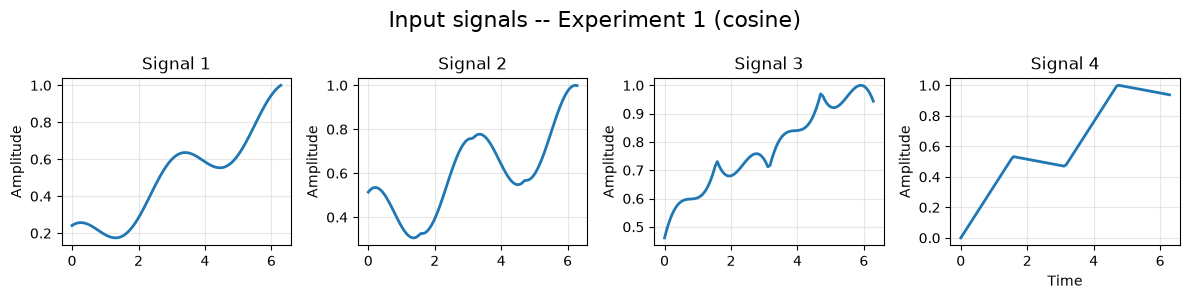

In [2]:
import scipy.signal as signal

np.random.seed(42)
t = np.linspace(0, 2 * np.pi, 100)

gt_basis = [np.cos(2 * t) + 1, signal.sawtooth(2 * t, 0.5)+1, t]

n_components = 3
X = np.vstack([gt_basis[0] + gt_basis[2],  1. * gt_basis[0] + 0.4 * gt_basis[1] + 0.3 * gt_basis[2],
                  0.9 * gt_basis[0] + 1.2 * gt_basis[1] + 0.3*gt_basis[2], 1.0 * gt_basis[1] + 1.0 * gt_basis[2] ])
X = X / np.max(np.abs(X), axis=1, keepdims=True)

num_signals = len(X)

fig, axes = plt.subplots(1, num_signals, figsize=(3*num_signals, 3))
fig.suptitle("Input signals -- Experiment 1 (cosine)", fontsize=16)
for i, ax in enumerate(axes):
    ax.plot(t, X[i], linewidth=2, color="tab:blue")
    ax.set_title(f"Signal {i + 1}")
    ax.grid(alpha=0.3)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

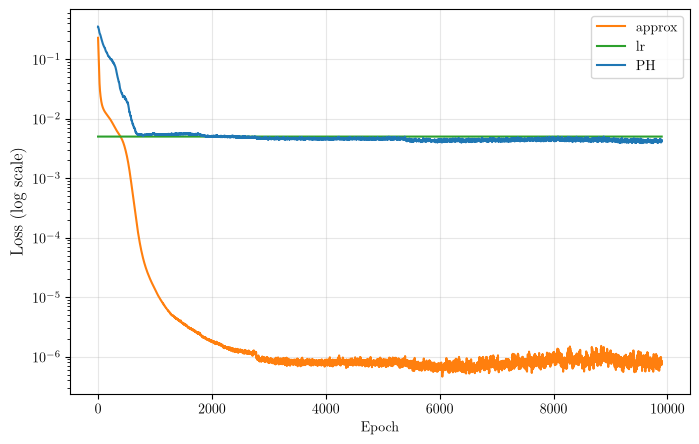

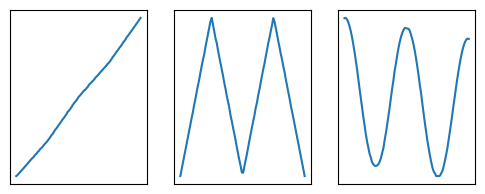

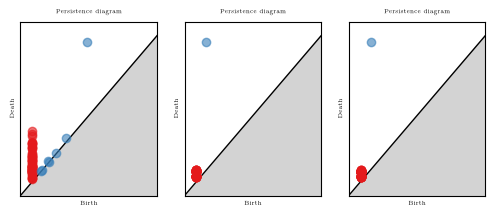

  0%|          | 0/10000 [00:00<?, ?it/s]

In [4]:
n_components = 3

# Periodicity score: 1 = perfectly periodic, 0 = non-periodic
embedding_dim = 4
tau = int(len(t) / (2 * (embedding_dim + 1)))

# target_periodicity=[1.0, 1.0, None] forces the first two bases to be periodic
target_periodicity=[1.0, 1.0, 0.0]

model_cos = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=42,
    use_embedding=True,
)

monitor_cos = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=100,
    factor=1.0,
    grid=(1, n_components),
)

model_cos.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.001,
    target_periodicity=target_periodicity,
    start_epoch_topological=0,
    embedding_dim=embedding_dim,
    basis_normalization="none",
    tau=tau,
    init_method="nndsvda",
    verbose=True,
    monitor=monitor_cos,
)

plt.close("all")

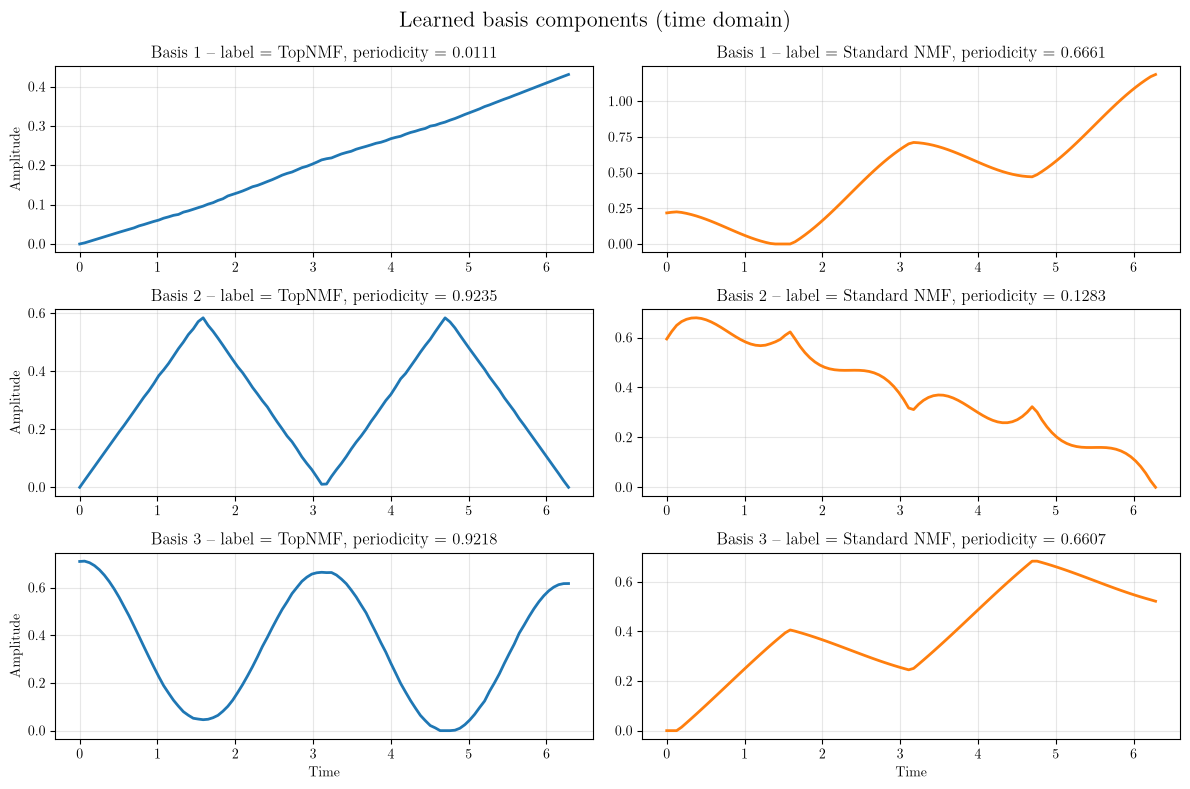

In [5]:
# Learned basis components in the time domain
fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (time domain)", fontsize=16)

V_top = model_cos.get_components()
W = model_cos.W.detach().cpu().numpy()
X_recon = model_cos.inverse_transform()

nmf = NMF(n_components=n_components, init="random", random_state=43)
W_nmf = nmf.fit_transform(X)
V_nmf = nmf.components_


for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
    for col in range(n_components):
        ax = axes[col, row]
        ax.plot(t, V[col], linewidth=2, color=color)
        score = compute_periodicity_score(V[col], embedding_dim=embedding_dim + 1, tau=tau)
        ax.set_title(f"Basis {col + 1} -- label = {label}, periodicity = {score:.4f}")
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_ylabel("Amplitude")
        if col == n_components - 1:
            ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

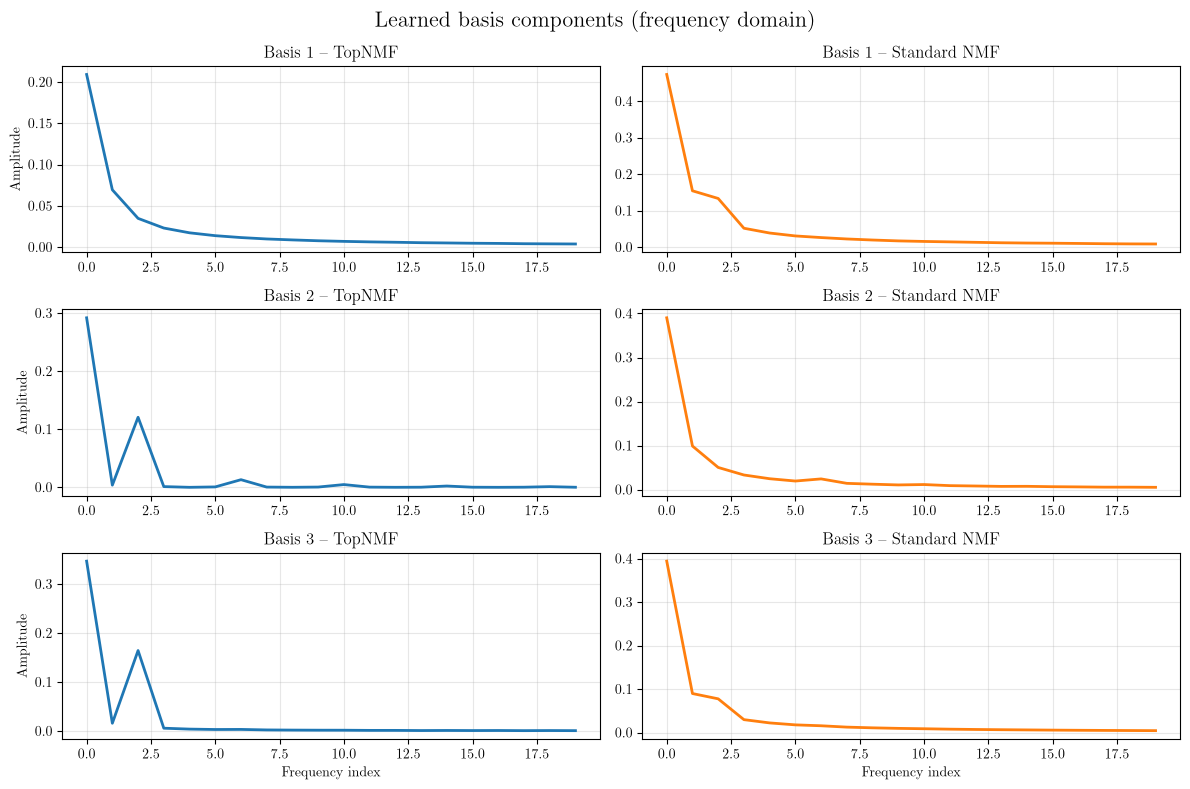

In [6]:
# Fourier spectra of the learned basis components
n_freq = 20

fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (frequency domain)", fontsize=16)

for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
        for col in range(n_components):
            spectrum = np.abs(np.fft.fft(V[col]))[:n_freq] / len(V[col])
            ax = axes[col, row]
            ax.plot(spectrum, linewidth=2, color=color)
            ax.set_title(f"Basis {col + 1} -- {label}")
            ax.grid(alpha=0.3)
            if row == 0:
                ax.set_ylabel("Amplitude")
            if col == n_components - 1:
                ax.set_xlabel("Frequency index")

plt.tight_layout()
plt.show()

#### Consolidated metric summary

In [7]:
# Consolidated metric summary -- Experiment 1 (periodic vs non-periodic, 3 atoms)
import pandas as pd
from IPython.display import display

atoms_exp1 = np.stack(gt_basis).astype(float)  # cosine, sawtooth, ramp


def _periodicity_list(V, edim, tau_):
    return [compute_periodicity_score(V[i], embedding_dim=edim + 1, tau=tau_)
            for i in range(V.shape[0])]


rows_exp1 = []
for name, Vm in [("Top-NMF", V_top), ("Standard NMF", V_nmf)]:
    per = _periodicity_list(Vm, embedding_dim, tau)
    rows_exp1.append({
        "method": name,
        "recon RMSE": recon_rmse_nnls(X, Vm),
        "atom recovery (cos)": atom_recovery_score(Vm, atoms_exp1),
        "periodicity gap": periodicity_gap(per),
        "# periodic bases (>0.5)": int(np.sum(np.array(per) > 0.5)),
    })
summary_exp1 = pd.DataFrame(rows_exp1).set_index("method")
print("Experiment 1 -- separate periodic atoms (cosine, sawtooth) from a non-periodic ramp.")
print("target_periodicity=[1, 1, 0] pushes two bases periodic. Reconstruction RMSE uses the")
print("optimal non-negative coefficients for each basis set (lower = better; atom recovery higher = better).")
display(summary_exp1.round(4))


Experiment 1 -- separate periodic atoms (cosine, sawtooth) from a non-periodic ramp.
target_periodicity=[1, 1, 0] pushes two bases periodic. Reconstruction RMSE uses the
optimal non-negative coefficients for each basis set (lower = better; atom recovery higher = better).


,recon RMSE,atom recovery (cos),periodicity gap,# periodic bases (>0.5)
method,,,,
Top-NMF,0.0009,0.9991,0.9124,2
Standard NMF,0.0030,0.8672,0.5379,2


---
## Part A2: Magnitude-based Alignment (Real-world Gait Data)

Extract and align walking signals from the UCI HAR dataset based on magnitude peaks, then apply **Top-NMF** to find topological basis components.

In [7]:
import os
import urllib.request
import zipfile

# 1. Configuration: Set URL and paths
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "UCI_HAR.zip"
extract_path = "UCI_HAR_Dataset"

# 2. Execution: Download and extract the dataset
if not os.path.exists(extract_path):
    print("🚀 Downloading UCI HAR Dataset... (approx. 60MB)")
    urllib.request.urlretrieve(url, zip_path)

    print("📦 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Remove the zip file after extraction to keep the directory clean
    os.remove(zip_path)
    print("✅ Setup complete!")
else:
    print("✨ Dataset folder already exists.")

# 3. Verification: Check if the data files are in place
test_file = os.path.join(extract_path, "UCI HAR Dataset", "train", "y_train.txt")
if os.path.exists(test_file):
    print(f"📍 Verification successful: {test_file}")

🚀 Downloading UCI HAR Dataset... (approx. 60MB)


📦 Extracting files...


✅ Setup complete!
📍 Verification successful: UCI_HAR_Dataset/UCI HAR Dataset/train/y_train.txt


In [8]:
import os
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# 1. Load 3-axis acceleration data (UCI HAR Dataset)
base_dir = os.path.join("UCI_HAR_Dataset", "UCI HAR Dataset", "train")

try:
    X_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_x_train.txt"))
    Y_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_y_train.txt"))
    Z_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_z_train.txt"))
    y_labels = np.loadtxt(os.path.join(base_dir, "y_train.txt")).astype(int)
    subjects = np.loadtxt(os.path.join(base_dir, "subject_train.txt")).astype(int)

    # Euclidean Magnitude
    Mag_raw = np.sqrt(X_acc**2 + Y_acc**2 + Z_acc**2)

    # 2. Subject-wise Alignment
    X_all_aligned = []
    window_size, align_idx = 128, 64

    for sub_id in np.unique(subjects):
        mask = (y_labels == 1) & (subjects == sub_id) # Walking data
        sub_mag_patches = Mag_raw[mask]
        if len(sub_mag_patches) == 0: continue

        sub_mag_signal = np.concatenate([patch[:64] for patch in sub_mag_patches])
        s_min, s_max = np.min(sub_mag_signal), np.max(sub_mag_signal)
        sub_mag_norm = (sub_mag_signal - s_min) / (s_max - s_min + 1e-9) + 0.1

        smoothed = gaussian_filter1d(sub_mag_norm, sigma=3)
        peaks, _ = find_peaks(smoothed, distance=40, prominence=0.15)

        for p in peaks:
            start, end = p - align_idx, p - align_idx + window_size
            if start >= 0 and end <= len(sub_mag_norm):
                X_all_aligned.append(sub_mag_norm[start:end])

    X_gait = np.array(X_all_aligned)
    print(f"Aligned Gait Data Shape: {X_gait.shape}")
except FileNotFoundError:
    print("UCI HAR Dataset not found. Please download and extract it to 'UCI_HAR_Dataset/'.")
    X_gait = None


Aligned Gait Data Shape: (1292, 128)


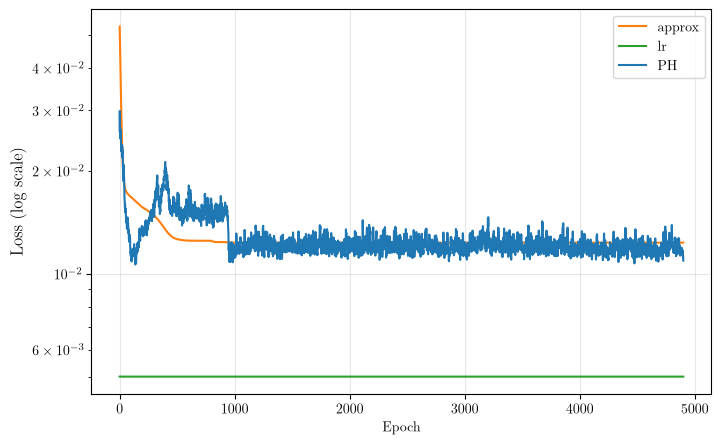

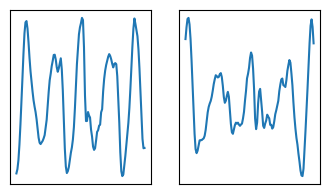

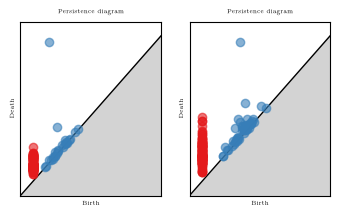

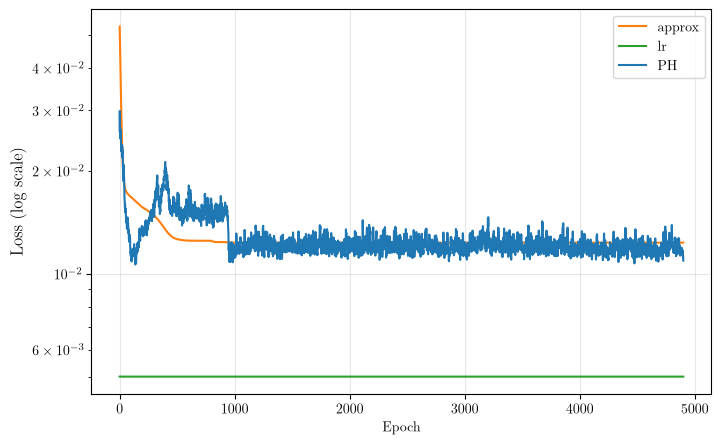

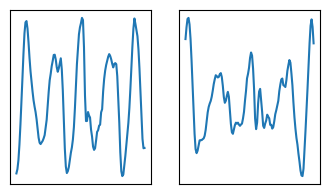

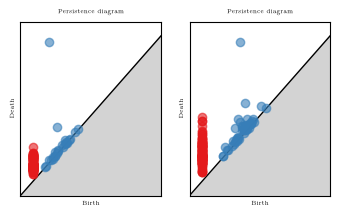

In [9]:
# 3. Fit Top-NMF on Gait Data
if X_gait is not None:
    n_components_gait = 2
    embedding_dim_gait = 10
    target_periodicity_gait = [1.0] + [None] * (n_components_gait - 1)

    model_gait = TopologicalNMF(
        n_components=n_components_gait,
        device=device,
        random_state=42,
        use_embedding=True,
    )

    monitor_gait = FitMonitor(
        show=["loss", "basis", "PH"],
        interval=100,
        factor=1.0,
        grid=(1, n_components_gait),
    )

    model_gait.fit(
        X_gait,
        n_iterations=5000,
        lr=0.005,
        lambda_apx=1.0,
        lambda_top=0.01,
        target_periodicity=target_periodicity_gait,
        start_epoch_topological=0,
        embedding_dim=embedding_dim_gait,
        n_periods=5,
        init_method="nndsvda",
        verbose=False,
        monitor=monitor_gait,
    )


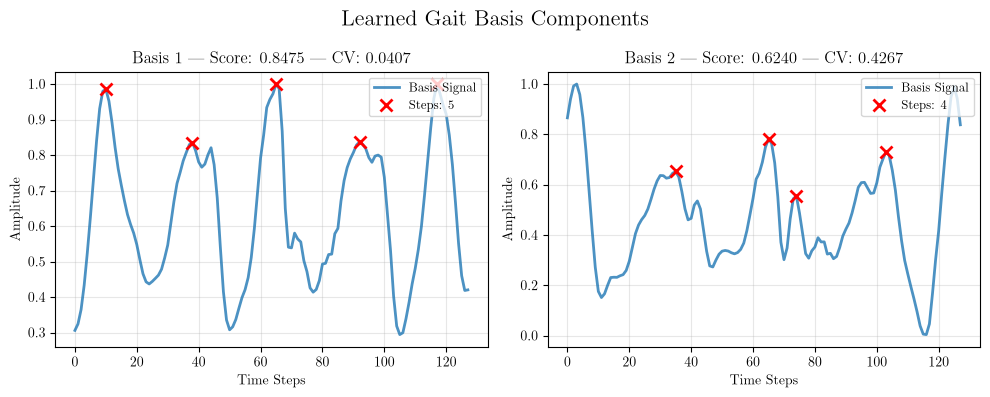

In [10]:
# 4. Visualize Learned Gait Basis (with Step Peaks & CV)
if X_gait is not None:
    tau_gait = int(model_gait.V.shape[1] / (5 * (embedding_dim_gait + 1)))

    fig, axes = plt.subplots(1, n_components_gait, figsize=(5 * n_components_gait, 4))
    fig.suptitle("Learned Gait Basis Components", fontsize=16)

    for i, ax in enumerate(axes):
        signal = model_gait.V[i].detach().cpu().numpy()
        time_steps = np.arange(len(signal))

        # 1. Plot Basis
        ax.plot(time_steps, signal, linewidth=2, color="tab:blue", alpha=0.8, label="Basis Signal")

        # 2. Find Peaks (Dynamic prominence based on signal range)
        signal_range = np.max(signal) - np.min(signal)
        dynamic_prominence = signal_range * 0.20
        peaks, _ = find_peaks(signal, distance=5, prominence=dynamic_prominence)

        # 3. Calculate Periodicity & CV
        score = compute_periodicity_score(model_gait.V[i], embedding_dim=embedding_dim_gait + 1, tau=tau_gait)

        if len(peaks) > 1:
            intervals = np.diff(peaks)
            cv_intervals = np.std(intervals) / np.mean(intervals)
        else:
            cv_intervals = 0.0

        # 4. Mark Peaks
        if len(peaks) > 0:
            ax.plot(peaks, signal[peaks], "rx", markersize=8, markeredgewidth=2, label=f"Steps: {len(peaks)}")

        ax.set_title(f"Basis {i + 1} | Score: {score:.4f} | CV: {cv_intervals:.4f}")
        ax.grid(alpha=0.3)
        ax.set_ylabel("Amplitude")
        ax.set_xlabel("Time Steps")
        ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()


#### Consolidated metric summary

In [11]:
# Consolidated metric summary -- Part A2 (real UCI-HAR gait)
if X_gait is not None:
    import pandas as pd
    from IPython.display import display

    V_top_gait = model_gait.V.detach().cpu().numpy()
    tau_gait = int(model_gait.V.shape[1] / (5 * (embedding_dim_gait + 1)))

    nmf_gait = NMF(n_components=n_components_gait, init="nndsvda", random_state=0, max_iter=10000)
    nmf_gait.fit_transform(X_gait)
    V_nmf_gait = nmf_gait.components_

    def _per_gait(V):
        return [compute_periodicity_score(V[i], embedding_dim=embedding_dim_gait + 1, tau=tau_gait)
                for i in range(V.shape[0])]

    rows_gait = []
    for name, Vm in [("Top-NMF", V_top_gait), ("Standard NMF", V_nmf_gait)]:
        per = _per_gait(Vm)
        rows_gait.append({
            "method": name,
            "recon RMSE": recon_rmse_nnls(X_gait, Vm),
            "max periodicity": float(max(per)),
            "periodicity gap": periodicity_gap(per),
        })
    summary_gait = pd.DataFrame(rows_gait).set_index("method")
    print("Part A2 -- real gait windows, no ground-truth atoms. The goal is to isolate a strongly")
    print("periodic gait-cycle basis; higher max periodicity / gap = cleaner periodic component.")
    display(summary_gait.round(4))
else:
    print("Gait summary skipped (UCI HAR dataset unavailable).")


Part A2 -- real gait windows, no ground-truth atoms. The goal is to isolate a strongly
periodic gait-cycle basis; higher max periodicity / gap = cleaner periodic component.


,recon RMSE,max periodicity,periodicity gap
method,,,
Top-NMF,0.1110,0.8475,0.2235
Standard NMF,0.1098,0.7729,0.1220


---
## Part B -- Unimodal basis (1-D cubical persistence)

Each basis vector should be **one connected blob** ($b_0 = 1$). On a 1-D
signal, vertex-mode superlevel cubical persistence measures how many distinct
local maxima a basis carries.

Here we use the weighted total squared persistence

$$
WTP_p^{(k)}(v) = \sum_{(b,d) \in PH_k^{\mathrm{fin}}(v)} (1-d)^p (d-b)^2,
\qquad p \ge 0.
$$

In B.1 we set $k=0$ and $p=2$, i.e. $WTP_2^{(0)}$. The death weight reduces the
influence of tiny low-level mergers and focuses the penalty on persistent
secondary peaks, yielding a unimodal shape without explicitly matching an empty
target diagram.


### B.1 Synthetic example -- Gaussian peak mixtures

Four ground-truth atoms, each a unimodal Gaussian centred at a distinct
position over $[0, 1]$. We observe six mixtures with random non-negative
coefficients and a small amount of detector-style noise. Top-NMF minimises
$WTP_2^{(0)}$ on every basis, while standard NMF only minimises reconstruction
error.


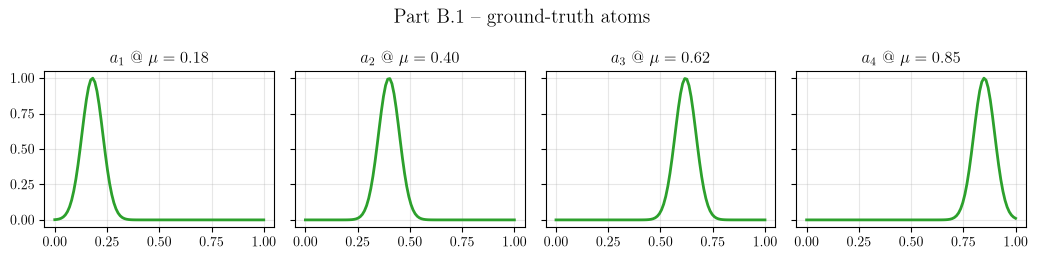

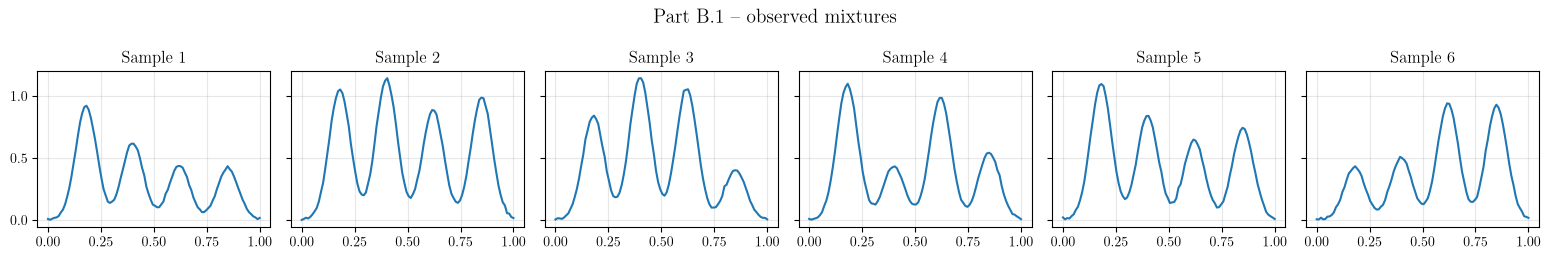

In [9]:
T_B1 = 100
x_B1 = np.linspace(0, 1, T_B1)
centers_B1 = np.array([0.18, 0.40, 0.62, 0.85])
sigma_B1 = 0.05
atoms_B1 = np.stack([
    np.exp(-((x_B1 - c) ** 2) / (2 * sigma_B1 ** 2)) for c in centers_B1
], axis=0).astype(np.float32)
n_components_B1 = atoms_B1.shape[0]

rng = np.random.default_rng(0)
n_samples_B1 = 6
W_true_B1 = rng.uniform(0.4, 1.2, size=(n_samples_B1, n_components_B1)).astype(np.float32)
X_B1 = (W_true_B1 @ atoms_B1).astype(np.float32)
X_B1 += 0.01 * np.abs(rng.standard_normal(X_B1.shape).astype(np.float32))
X_B1 = np.clip(X_B1, 0, None)

fig, axes = plt.subplots(1, n_components_B1, figsize=(2.6 * n_components_B1, 2.6), sharey=True)
fig.suptitle("Part B.1 -- ground-truth atoms", fontsize=14)
for i, ax in enumerate(axes):
    ax.plot(x_B1, atoms_B1[i], lw=2, color="tab:green")
    ax.set_title(f"$a_{i + 1}$ @ $\\mu={centers_B1[i]:.2f}$")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, n_samples_B1, figsize=(2.6 * n_samples_B1, 2.6), sharey=True)
fig.suptitle("Part B.1 -- observed mixtures", fontsize=14)
for i, ax in enumerate(axes):
    ax.plot(x_B1, X_B1[i], lw=1.5, color="tab:blue")
    ax.set_title(f"Sample {i + 1}")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### Fit Top-NMF and standard NMF

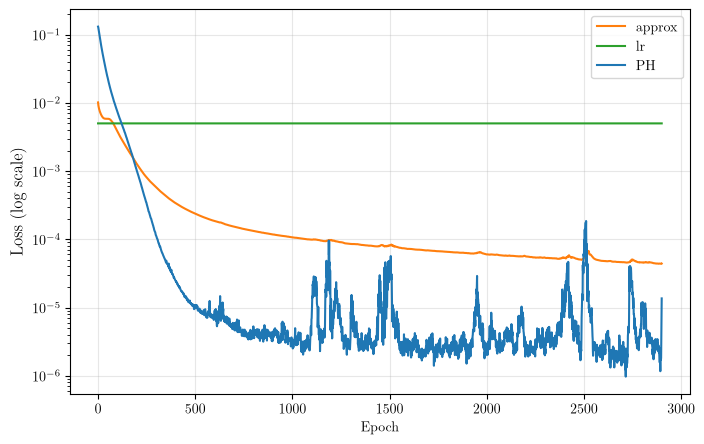

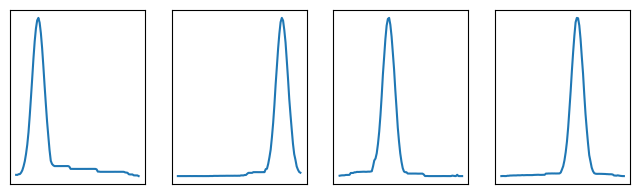

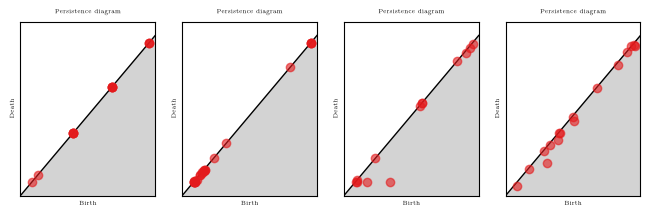

  0%|          | 0/3000 [00:00<?, ?it/s]

In [10]:
cubical_B1 = CubicalComplex(superlevel=True, dim=1, mode="V")
# TopologicalNMF currently calls ph_loss_fn when target_diagrams is not None;
# WTP ignores these placeholders and directly evaluates the computed diagram.
target_diagrams_B1 = [None]

model_B1 = TopologicalNMF(
    n_components=n_components_B1,
    device=device,
    random_state=0,
    complex=cubical_B1,
    ph_loss_fn=weighted_total_squared_persistence_loss,
    ph_loss_params={"power": 2.0},
    data_shape=(T_B1,),
    use_embedding=False,
)
monitor_B1 = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=100,
    factor=1.0,
    grid=(1, n_components_B1),
    PHmode="V",
    superlevel=True,
    save_video=True,
)
model_B1.fit(
    X_B1,
    n_iterations=3000,
    lr=0.005,
    lambda_top=0.5,
    PH_dims=[0],
    target_diagrams=target_diagrams_B1,
    basis_normalization="none",
    init_method="nndsvdar",
    verbose=True,
    monitor=monitor_B1,
)
plt.close("all")

V_top_B1 = model_B1.get_components()
W_top_B1 = model_B1.W.detach().cpu().numpy()

nmf_B1 = NMF(n_components=n_components_B1, init="nndsvda", random_state=0, max_iter=10000)
W_nmf_B1 = nmf_B1.fit_transform(X_B1)
V_nmf_B1 = nmf_B1.components_


In [14]:
monitor_B1.save(os.path.join(OUTPUT_DIR, "unimodal.mp4"), show=["basis","PH"], fps=5)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 226) to (1600, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook/output/unimodal.mp4


#### Compare learned bases

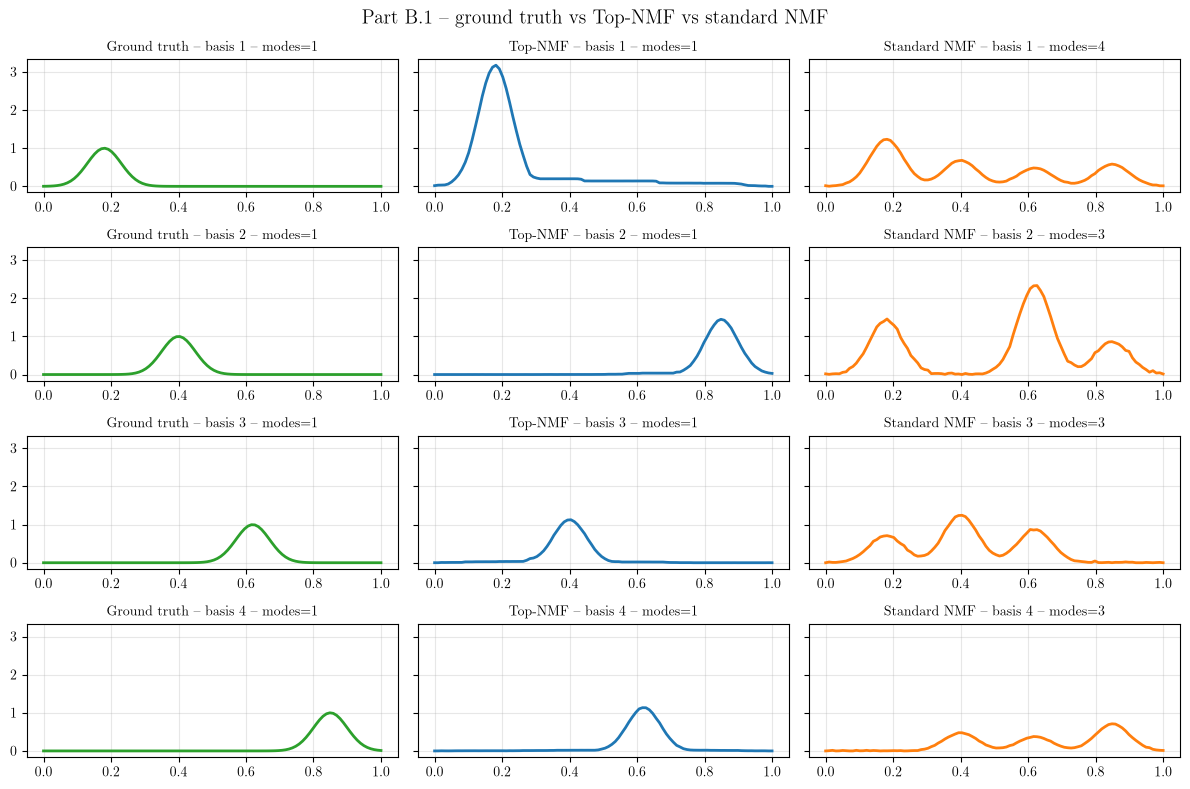

In [11]:
fig, axes = plt.subplots(n_components_B1, 3, figsize=(12, 8), sharey=True)
fig.suptitle("Part B.1 -- ground truth vs Top-NMF vs standard NMF", fontsize=14)
columns_B1 = [
    ("Ground truth", atoms_B1, "tab:green"),
    ("Top-NMF", V_top_B1, "tab:blue"),
    ("Standard NMF", V_nmf_B1, "tab:orange"),
]
for col, (label, V, color) in enumerate(columns_B1):
    for row in range(n_components_B1):
        ax = axes[row, col]
        ax.plot(x_B1, V[row], lw=2, color=color)
        ax.set_title(f"{label} -- basis {row + 1} -- modes={count_modes(V[row])}", fontsize=10)
        ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


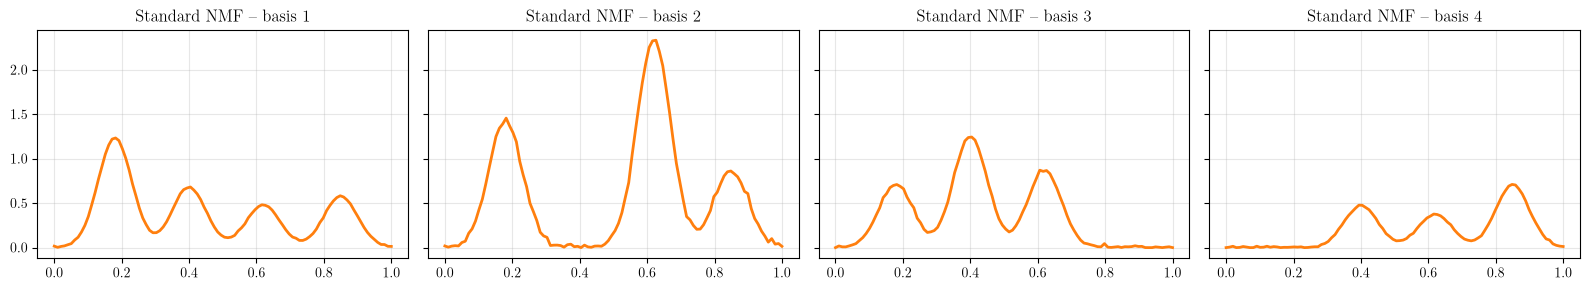

In [12]:
fig, axes = plt.subplots(1, V_nmf_B1.shape[0], figsize=(4 * V_nmf_B1.shape[0], 3), sharey=True)

if V_nmf_B1.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(x_B1, V_nmf_B1[i], lw=2, color="tab:orange")
    ax.set_title(f"Standard NMF -- basis {i + 1}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Quantitative comparison

In [13]:
mae_top_B1, _, _ = basis_peak_position_mae(V_top_B1, x_B1, centers_B1)
mae_nmf_B1, _, _ = basis_peak_position_mae(V_nmf_B1, x_B1, centers_B1)


def wtp0_2_values_B1(V: np.ndarray) -> list:
    values = []
    for v in V:
        tensor_v = torch.as_tensor(v, dtype=torch.float, device=device)
        diagrams = cubical_B1(tensor_v)
        loss = weighted_total_squared_persistence_loss(diagrams, [0], device=device, power=2.0)
        values.append(float(loss.detach().cpu()))
    return values

wtp_top_B1 = wtp0_2_values_B1(V_top_B1)
wtp_nmf_B1 = wtp0_2_values_B1(V_nmf_B1)

print(f"""Modes per basis (target = 1, lower mixture means more multi-peak leakage):
  Ground truth : {[count_modes(a) for a in atoms_B1]}
  Top-NMF      : {[count_modes(v) for v in V_top_B1]}
  Standard NMF : {[count_modes(v) for v in V_nmf_B1]}

WTP_2^{(0)} per basis (lower = fewer persistent secondary peaks):
  Top-NMF      : {[round(v, 5) for v in wtp_top_B1]}
  Standard NMF : {[round(v, 5) for v in wtp_nmf_B1]}

Atom recovery (cosine similarity, higher = better):
  Top-NMF      : {atom_recovery_score(V_top_B1, atoms_B1):.3f}
  Standard NMF : {atom_recovery_score(V_nmf_B1, atoms_B1):.3f}

Peak-position MAE (lower = better):
  Top-NMF      : {mae_top_B1:.3f}
  Standard NMF : {mae_nmf_B1:.3f}

Reconstruction RMSE:
  Top-NMF      : {reconstruction_rmse(X_B1, W_top_B1, V_top_B1):.4f}
  Standard NMF : {reconstruction_rmse(X_B1, W_nmf_B1, V_nmf_B1):.4f}""")


Modes per basis (target = 1, lower mixture means more multi-peak leakage):
  Ground truth : [1, 1, 1, 1]
  Top-NMF      : [1, 1, 1, 1]
  Standard NMF : [4, 3, 3, 3]

WTP_2^0 per basis (lower = fewer persistent secondary peaks):
  Top-NMF      : [0.0, 0.0, 0.0, 1e-05]
  Standard NMF : [0.50554, 2.3973, 0.52987, 0.21585]

Atom recovery (cosine similarity, higher = better):
  Top-NMF      : 0.998
  Standard NMF : 0.772

Peak-position MAE (lower = better):
  Top-NMF      : 0.003
  Standard NMF : 0.003

Reconstruction RMSE:
  Top-NMF      : 0.0066
  Standard NMF : 0.0037


#### Consolidated metric summary

In [14]:
# Consolidated metric summary -- Part B.1 (unimodal Gaussian atoms)
import pandas as pd
from IPython.display import display


def _mean_modes(V):
    return float(np.mean([count_modes(v) for v in V]))


def _mean_wtp(V):
    return float(np.mean(wtp0_2_values_B1(V)))


rows_B1 = []
for name, Vm in [("Top-NMF", V_top_B1), ("Standard NMF", V_nmf_B1)]:
    mae, _, _ = basis_peak_position_mae(Vm, x_B1, centers_B1)
    rows_B1.append({
        "method": name,
        "recon RMSE": recon_rmse_nnls(X_B1, Vm),
        "atom recovery (cos)": atom_recovery_score(Vm, atoms_B1),
        "peak-position MAE": mae,
        "mean modes (target 1)": _mean_modes(Vm),
        "mean WTP_2^(0)": _mean_wtp(Vm),
    })
summary_B1 = pd.DataFrame(rows_B1).set_index("method")
print("Part B.1 -- recover unimodal Gaussian atoms. Top-NMF minimises WTP_2^(0) so each basis is")
print("a single connected peak. Lower modes / WTP / peak-MAE and higher atom recovery = cleaner atoms.")
display(summary_B1.round(4))


Part B.1 -- recover unimodal Gaussian atoms. Top-NMF minimises WTP_2^(0) so each basis is
a single connected peak. Lower modes / WTP / peak-MAE and higher atom recovery = cleaner atoms.


,recon RMSE,atom recovery (cos),peak-position MAE,mean modes (target 1),mean WTP_2^(0)
method,,,,,
Top-NMF,0.0066,0.9980,0.0028,1.00,0.0000
Standard NMF,0.0037,0.7723,0.0034,3.25,0.9121
